# Práctica 4: Pruebas estadísticas

El objetivo es comprobar si existen diferencias significativas entre grupos de datos etiquetados, usando ANOVA + prueba t o la prueba de Kruskal-Wallis 

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 40)

PATH_INPUT = "../data/processed/spotify_cleaned.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ALPHA = 0.05

## 0. Carga de datos

In [2]:
df = pd.read_csv(PATH_INPUT)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.")
df.head()

Dimensiones: 66174 filas x 36 columnas.


,unnamed_0,uri,rank,artist_names,artists_num,artist_individual,artist_id,artist_genre,artist_img,collab,track_name,release_date,album_num_tracks,album_cover,source,peak_rank,previous_rank,weeks_on_chart,streams,week,danceability,energy,key,mode,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,country,region,language,pivot
0,29477,spotify:track:4ZtFanR9U6ndgddUvNcjcG,1,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,good 4 u,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,1,1,3,3612666,03-06-2021,0.563,0.664,9,1,-5.044,0.1540,0.335,0.000000,0.0849,0.6880,166.928,178147,Australia,Oceania,English,0
1,29478,spotify:track:6HU7h9RYOaPRFeh0R3UeAr,3,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,deja vu,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,2,2,9,1666474,03-06-2021,0.442,0.612,2,1,-7.222,0.1120,0.584,0.000006,0.3700,0.1780,180.917,215507,Australia,Oceania,English,0
2,29479,spotify:track:5CZ40GBx1sQ9agT82CLQCT,4,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,traitor,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,4,6,2,1433290,03-06-2021,0.380,0.339,3,1,-7.885,0.0338,0.691,0.000000,0.1200,0.0849,100.607,229227,Australia,Oceania,English,0
3,29480,spotify:track:5wANPM4fQCJwkGd4rN57mH,6,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,drivers license,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,1,5,21,1266266,03-06-2021,0.561,0.431,10,1,-8.810,0.0578,0.768,0.000014,0.1060,0.1370,143.875,242013,Australia,Oceania,English,0
4,29481,spotify:track:5JCoSi02qi3jJeHdZXMmR8,7,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,favorite crime,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,7,15,2,1184068,03-06-2021,0.369,0.272,9,1,-10.497,0.0364,0.866,0.000000,0.1470,0.2180,172.929,152667,Australia,Oceania,English,0


## 1. Preparación de los datos

La tabla está desnormalizada, por lo que una misma canción aparece repetida una vez por semana y por artista dentro de un mismo país, así que antes de comparar países se agrupa a una fila por canción-país, tomando `danceability` y el promedio semanal de `streams`.

In [3]:
cancion_pais = df.groupby(["uri", "country"], as_index=False).agg(
    danceability=("danceability", "first"),
    streams=("streams", "mean"),
)
PAISES = sorted(cancion_pais["country"].unique())

print(f"cancion_pais: {len(cancion_pais)} filas")
cancion_pais.groupby("country").size()

cancion_pais: 4548 filas


country
Australia    1305
Canada       1785
Ireland      1458
dtype: int64

**Hipótesis (las mismas para las dos pruebas, α = 0.05):**

- H₀: las medias / distribuciones de la variable son iguales entre los tres países.
- H₁: al menos un país difiere de los demás.

## 2. Prueba 1: ANOVA + prueba t: `danceability` por país

### Supuestos

In [4]:
grupos_dance = [cancion_pais.loc[cancion_pais["country"] == p, "danceability"] for p in PAISES]

for p, g in zip(PAISES, grupos_dance):
    muestra = g.sample(500, random_state=42) if len(g) > 500 else g
    W, p_shapiro = stats.shapiro(muestra)
    print(f"Shapiro-Wilk {p}: W={W:.3f}  p={p_shapiro:.2e}")

L, p_levene = stats.levene(*grupos_dance)
print(f"\nLevene (igualdad de varianzas): F={L:.3f}  p={p_levene:.4f}")

Shapiro-Wilk Australia: W=0.980  p=2.79e-06
Shapiro-Wilk Canada: W=0.987  p=1.65e-04
Shapiro-Wilk Ireland: W=0.979  p=1.25e-06

Levene (igualdad de varianzas): F=0.014  p=0.9858


Shapiro-Wilk rechaza la normalidad estricta en los tres países, pero W es muy alto (0.98), eso nos dice que la desviación es mínima y se debe sobre todo al tamaño de muestra (1,305–1,785 canciones por país). El ANOVA es robusto ante desviaciones leves de normalidad con grupos grandes. Levene sí acepta la igualdad de varianzas (p = 0.986), así que se cumple el segundo supuesto y se procede con la vía paramétrica.

### ANOVA

In [5]:
F, p_anova = stats.f_oneway(*grupos_dance)
print(f"ANOVA: F = {F:.3f}   p = {p_anova:.4f}")

cancion_pais.groupby("country")["danceability"].mean().loc[PAISES].round(3)

ANOVA: F = 7.220   p = 0.0007


country
Australia    0.643
Canada       0.656
Ireland      0.637
Name: danceability, dtype: float64

Con p = 0.0007 (< α) se rechaza H₀: al menos un país tiene una `danceability` promedio distinta. El ANOVA nos indica que hay una diferencia, pero no cuál par de países la produce.

### Prueba t, para saber entre qué países está la diferencia

In [6]:
canada = cancion_pais.loc[cancion_pais["country"] == "Canada", "danceability"]
irlanda = cancion_pais.loc[cancion_pais["country"] == "Ireland", "danceability"]

t, p_t = stats.ttest_ind(canada, irlanda)
print(f"Canadá (media={canada.mean():.3f})  vs  Irlanda (media={irlanda.mean():.3f})")
print(f"t = {t:.3f}   p = {p_t:.4f}")

Canadá (media=0.656)  vs  Irlanda (media=0.637)
t = 3.686   p = 0.0002


Canadá (0.656) e Irlanda (0.637) son los países con la mayor diferencia de medias en el paso anterior. Con la prueba t confirmamos que la diferencia es significativa (p = 0.0002 < α) y por lo tanto se rechaza H₀, lo que indica que las canciones del top canadiense son en promedio un poco más bailables que las del top irlandés.

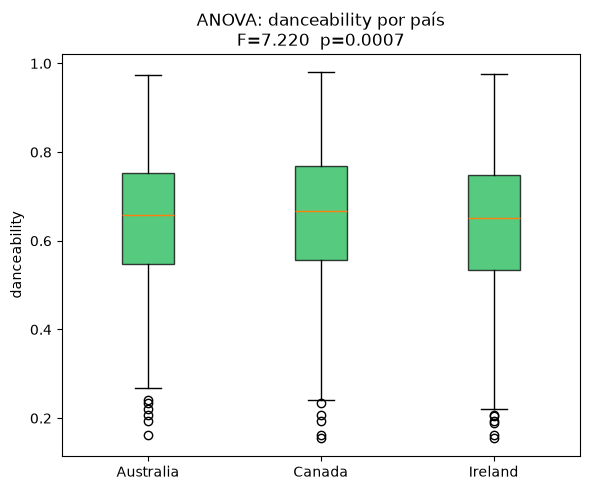

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
data = [cancion_pais.loc[cancion_pais["country"] == p, "danceability"] for p in PAISES]
ax.boxplot(data, tick_labels=PAISES, patch_artist=True,
           boxprops=dict(facecolor="#1DB954", alpha=0.75))
ax.set_ylabel("danceability")
ax.set_title(f"ANOVA: danceability por país\nF={F:.3f}  p={p_anova:.4f}")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "anova_danceability_pais.png"), dpi=150)
plt.show()

## 3. Prueba 2: Kruskal-Wallis:`streams` por país

### Supuestos

En la Práctica 2 se vio que `streams` tiene una asimetría de 3.11 y una curtosis de 17.66, así que aquí se espera que los supuestos del ANOVA fallen.

In [8]:
grupos_streams = [cancion_pais.loc[cancion_pais["country"] == p, "streams"] for p in PAISES]

for p, g in zip(PAISES, grupos_streams):
    muestra = g.sample(500, random_state=42) if len(g) > 500 else g
    W, p_shapiro = stats.shapiro(muestra)
    print(f"Shapiro-Wilk {p}: W={W:.3f}  p={p_shapiro:.2e}")

L, p_levene = stats.levene(*grupos_streams)
print(f"\nLevene (igualdad de varianzas): F={L:.3f}  p={p_levene:.2e}")

Shapiro-Wilk Australia: W=0.613  p=6.27e-32
Shapiro-Wilk Canada: W=0.671  p=5.54e-30
Shapiro-Wilk Ireland: W=0.641  p=5.17e-31

Levene (igualdad de varianzas): F=151.614  p=1.81e-64


Shapiro-Wilk da valores de W entre 0.61 y 0.67 (muy lejos de 1) y Levene rechaza la igualdad de varianzas con p < 0.0001. `streams` es una variable fuertemente asimétrica y con colas largas: no se cumple ninguno de los dos supuestos, así que se usa la prueba no paramétrica de Kruskal-Wallis en vez de ANOVA.

### Kruskal-Wallis

In [9]:
H, p_kw = stats.kruskal(*grupos_streams)
print(f"Kruskal-Wallis: H = {H:.3f}   p = {p_kw:.2e}")

cancion_pais.groupby("country")["streams"].median().loc[PAISES].round(1)

Kruskal-Wallis: H = 2847.391   p = 0.00e+00


country
Australia    300293.8
Canada       298815.6
Ireland       57893.5
Name: streams, dtype: float64

Con p ≈ 0 (< α) se rechaza H₀: la distribución de `streams` no es la misma entre los tres países. Viendo las medianas, Australia (300,294) y Canadá (298,816) son muy parecidas, mientras que Irlanda (57,894) queda muy por debajo. Esto es coherente con la población de cada país.

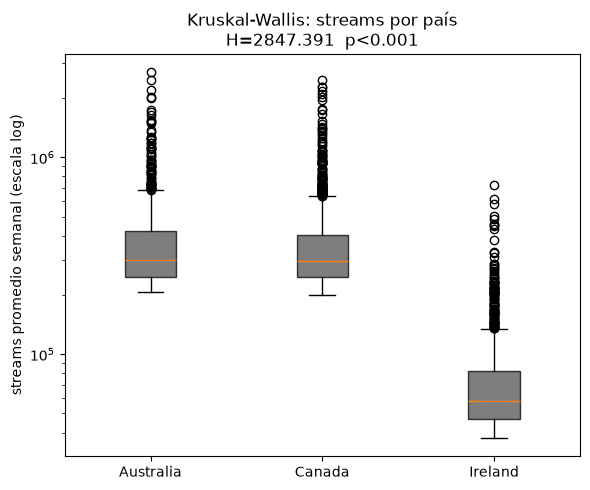

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(grupos_streams, tick_labels=PAISES, patch_artist=True,
           boxprops=dict(facecolor="#535353", alpha=0.75))
ax.set_yscale("log")
ax.set_ylabel("streams promedio semanal (escala log)")
ax.set_title(f"Kruskal-Wallis: streams por país\nH={H:.3f}  p<0.001")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "kruskal_streams_pais.png"), dpi=150)
plt.show()

## 4. Conclusiones

- En `danceability`, los supuestos de normalidad (aproximada) y homocedasticidad se cumplen razonablemente, por lo que se usó ANOVA + prueba t encontrando una diferencia significativa entre países, con Canadá ligeramente más bailable que Irlanda.
- En `streams`, la variable es muy asimétrica y con varianzas desiguales entre países, por lo que se usó Kruskal-Wallis encontrando una diferencia significativa y muy marcada, con Irlanda muy por debajo de Australia y Canadá.
- Elegir la prueba correcta según los supuestos importa: si se hubiera aplicado ANOVA directamente sobre `streams` sin revisar Shapiro-Wilk y Levene, el resultado habría sido inválido por no respetar sus condiciones.